# Dataset 1: Titanic — Data Cleaning, Preprocessing & Feature Engineering

**Source:** Titanic passenger manifest (classic Kaggle "Titanic: Machine Learning from Disaster" dataset),
mirrored at `datasciencedojo/datasets` on GitHub.

**Goal:** Predict passenger survival (`Survived`). This notebook is heavily **categorical / mixed-type**
focused, and covers: data-quality auditing, deliberate corruption + cleanup, missing-value treatment,
categorical encoding, feature engineering, outlier handling, train/val/test splitting, data-leakage
pitfalls, and a reusable scikit-learn `Pipeline`.


In [1]:

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
np.random.seed(42)

RAW_PATH = "data/titanic_raw.csv"
MESSY_PATH = "data/titanic_messy.csv"
CLEAN_PATH = "data/titanic_cleaned.csv"

df_raw = pd.read_csv(RAW_PATH)
print(df_raw.shape)
df_raw.head()


(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Data Quality Assessment (on the original file)

Before touching anything, audit the dataset for the seven classic data-quality problems:
missing values, duplicate records, invalid values, inconsistent categories, incorrect data types,
outliers, and noisy data.


In [2]:

print("dtypes:")
print(df_raw.dtypes)
print("\nMissing values per column:")
print(df_raw.isna().sum())
print("\nMissing % per column:")
print((df_raw.isna().mean()*100).round(1))
print("\nExact duplicate rows:", df_raw.duplicated().sum())
print("\nUnique values - Sex:", df_raw['Sex'].unique())
print("Unique values - Embarked:", df_raw['Embarked'].unique())
print("Unique values - Pclass:", df_raw['Pclass'].unique())


dtypes:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing % per column:
PassengerId     0.0
Survived        0.0
Pclass          0.0
Name            0.0
Sex             0.0
Age            19.9
SibSp           0.0
Parch           0.0
Ticket          0.0
Fare            0.0
Cabin          77.1
Embarked        0.2
dtype: float64

Exact duplicate rows: 0

Unique values - Sex: <StringArray>
['male', 'female']
Length: 2, dtype: str
Unique values - Embarked: <StringArray>
['S', 'C', 'Q

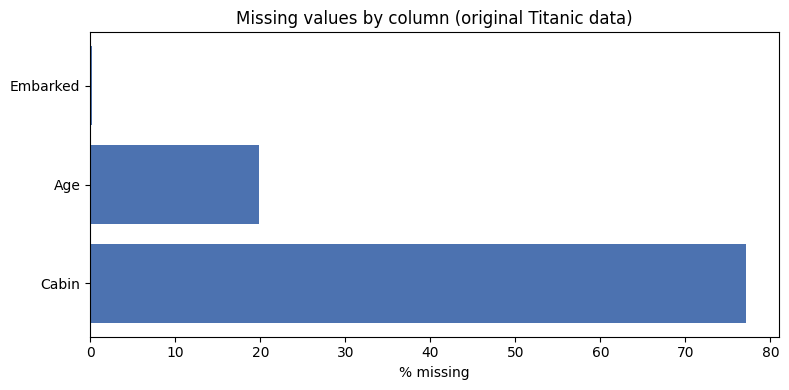

In [3]:

fig, ax = plt.subplots(figsize=(8,4))
missing = df_raw.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
ax.barh(missing.index, missing.values*100, color="#4C72B0")
ax.set_xlabel("% missing")
ax.set_title("Missing values by column (original Titanic data)")
plt.tight_layout()
plt.savefig("figs/titanic_missing_original.png", dpi=110)
plt.show()


The real dataset already shows two of the seven problems out of the box: **missing values**
(`Age` ~20%, `Cabin` ~77%, `Embarked` 2 rows) and **incorrect data type** (`Pclass` is really an
ordinal category stored as `int64`). It has no duplicates, invalid values, or inconsistent category
casing — real Kaggle exports are usually reasonably clean. To practice handling *all seven* problems
(Practical Task 1: "clean a deliberately messy dataset"), we now inject the remaining issues on a copy.


## 2. Building a Deliberately Messy Version

We copy the raw data and deliberately introduce every remaining data-quality problem so the rest of
the notebook has real issues to clean:

- **Duplicate records** — repeat 20 random rows
- **Invalid values** — negative `Age`, `Fare` of 0 for paying classes, `Age` of 200
- **Inconsistent categories** — mixed casing / spacing in `Sex` and `Embarked` (`'male'`, `'MALE'`, `' Male'`)
- **Incorrect data types** — `Age` and `Fare` stored as text with stray characters (`"22"`, `"twenty"`, `"7.25 "`)
- **Outliers** — a few extreme `Fare` values (500+)
- **Noisy data** — free-text noise in `Name` (extra whitespace, stray symbols)


In [4]:

messy = df_raw.copy()
rng = np.random.RandomState(42)

# 1. Duplicate records
dup_rows = messy.sample(20, random_state=1)
messy = pd.concat([messy, dup_rows], ignore_index=True)

# 2. Invalid values
neg_idx = rng.choice(messy.index, 5, replace=False)
messy.loc[neg_idx, "Age"] = -messy.loc[neg_idx, "Age"].fillna(20)
zero_fare_idx = rng.choice(messy.index, 5, replace=False)
messy.loc[zero_fare_idx, "Fare"] = 0
extreme_age_idx = rng.choice(messy.index, 3, replace=False)
messy.loc[extreme_age_idx, "Age"] = 200

# 3. Inconsistent categories
messy["Sex"] = messy["Sex"].astype(object)
mask = rng.rand(len(messy)) < 0.08
sel = mask & (messy["Sex"]=="male")
messy.loc[sel, "Sex"] = rng.choice(["MALE"," male","Male "], sel.sum())
messy["Embarked"] = messy["Embarked"].astype(object)
mask2 = rng.rand(len(messy)) < 0.06
messy.loc[mask2 & messy["Embarked"].notna(), "Embarked"] = messy.loc[mask2 & messy["Embarked"].notna(), "Embarked"].str.lower()

# 4. Incorrect data types - inject text noise into numeric columns
messy["Age"] = messy["Age"].astype(object)
text_age_idx = rng.choice(messy.index, 6, replace=False)
messy.loc[text_age_idx, "Age"] = "twenty"
messy["Fare"] = messy["Fare"].astype(object)
space_fare_idx = rng.choice(messy.index, 8, replace=False)
messy.loc[space_fare_idx, "Fare"] = messy.loc[space_fare_idx, "Fare"].astype(str) + " "

# 5. Outliers
outlier_idx = rng.choice(messy.index, 4, replace=False)
messy.loc[outlier_idx, "Fare"] = rng.uniform(400, 600, 4)

# 6. Noisy text data
noisy_idx = rng.choice(messy.index, 10, replace=False)
messy.loc[noisy_idx, "Name"] = "   " + messy.loc[noisy_idx, "Name"].astype(str) + "  ***"

messy.to_csv(MESSY_PATH, index=False)
print("Messy shape:", messy.shape)
messy.sample(8, random_state=3)


Messy shape: (911, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
732,733,0,2,"Knight, Mr. Robert J",male,NaN,0,0,239855,0.0,NaN,S
589,590,0,3,"Murdlin, Mr. Joseph",male,NaN,0,0,A./5. 3235,8.05,NaN,S
449,450,1,1,"Peuchen, Major. Arthur Godfrey",male,52.0,0,0,113786,30.5,C104,S
157,158,0,3,"Corn, Mr. Harry",male,30.0,0,0,SOTON/OQ 392090,8.05,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0,B22,S
48,49,0,3,"Samaan, Mr. Youssef",male,NaN,2,0,2662,21.6792,NaN,C
51,52,0,3,"Nosworthy, Mr. Richard Cater",male,21.0,0,0,A/4. 39886,7.8,NaN,S
676,677,0,3,"Sawyer, Mr. Frederick Charles",male,24.5,0,0,342826,8.05,NaN,S


In [5]:

# Re-audit the messy dataset — confirm every problem is present and measurable
issues = {}
issues["duplicate_rows"] = messy.duplicated().sum()
issues["missing_values_total"] = messy.isna().sum().sum()
issues["negative_or_extreme_age"] = ((pd.to_numeric(messy["Age"], errors="coerce") < 0) |
                                      (pd.to_numeric(messy["Age"], errors="coerce") > 100)).sum()
issues["zero_fare"] = (pd.to_numeric(messy["Fare"], errors="coerce") == 0).sum()
issues["inconsistent_sex_categories"] = messy["Sex"].nunique()
issues["inconsistent_embarked_categories"] = messy["Embarked"].nunique()
issues["age_wrong_dtype"] = messy["Age"].dtype
issues["fare_wrong_dtype"] = messy["Fare"].dtype
for k,v in issues.items():
    print(f"{k}: {v}")


duplicate_rows: 18
missing_values_total: 884
negative_or_extreme_age: 8
zero_fare: 20
inconsistent_sex_categories: 5
inconsistent_embarked_categories: 6
age_wrong_dtype: object
fare_wrong_dtype: object


## 3. Cleaning the Messy Dataset

We fix problems in a deliberate order: **dtypes → duplicates → inconsistent categories → invalid
values → outliers**, so each step operates on trustworthy input.


In [6]:

clean = messy.copy()

# --- Fix incorrect data types ---
clean["Age"] = pd.to_numeric(clean["Age"], errors="coerce")   # "twenty" -> NaN
clean["Fare"] = pd.to_numeric(clean["Fare"].astype(str).str.strip(), errors="coerce")
clean["Pclass"] = clean["Pclass"].astype("category")

# --- Remove duplicate records ---
before = len(clean)
clean = clean.drop_duplicates()
print(f"Removed {before - len(clean)} exact duplicate rows")

# --- Fix inconsistent categories ---
clean["Sex"] = clean["Sex"].astype(str).str.strip().str.lower()
clean["Embarked"] = clean["Embarked"].astype(str).str.strip().str.upper().replace("NAN", np.nan)
print("Sex categories after cleaning:", clean["Sex"].unique())
print("Embarked categories after cleaning:", clean["Embarked"].unique())

# --- Fix invalid values ---
clean.loc[clean["Age"] < 0, "Age"] = np.nan          # negative age -> unknown
clean.loc[clean["Age"] > 100, "Age"] = np.nan         # age of 200 -> unknown
clean.loc[clean["Fare"] <= 0, "Fare"] = np.nan        # fare of 0 -> unknown (except known free tickets)

# --- Clean noisy text ---
clean["Name"] = clean["Name"].astype(str).str.strip().str.replace(r"\*+", "", regex=True).str.strip()

print("\nRemaining missing values:")
print(clean.isna().sum())


Removed 18 exact duplicate rows
Sex categories after cleaning: <StringArray>
['male', 'female']
Length: 2, dtype: str
Embarked categories after cleaning: <StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

Remaining missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            189
SibSp            0
Parch            0
Ticket           0
Fare            20
Cabin          689
Embarked         2
dtype: int64


## 4. Outlier Detection (IQR method)

We flag outliers in `Fare` and `Age` using the 1.5×IQR rule, then decide on a treatment (capping,
a.k.a. *winsorization*) rather than deletion, since Fare outliers are legitimate (first-class,
large families) and we don't want to lose those passengers.


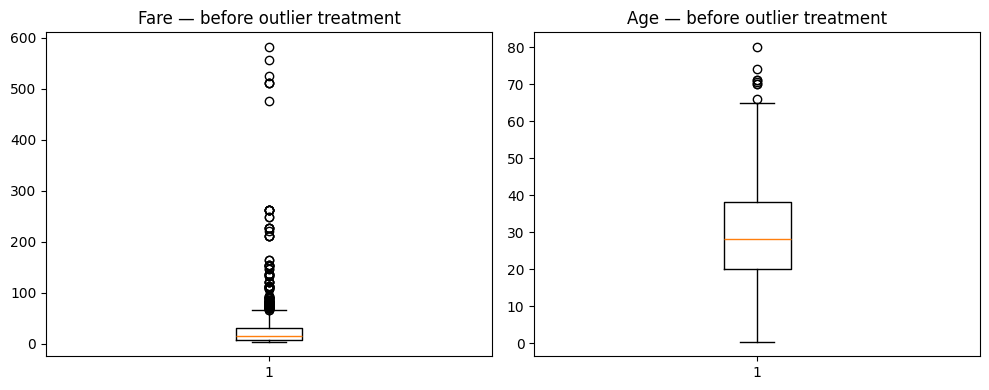

Fare IQR bounds: [-27.10, 66.30]  -> 119 high outliers
Age  IQR bounds: [-7.00, 65.00]  -> 8 high outliers


In [7]:

def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].boxplot(clean["Fare"].dropna())
axes[0].set_title("Fare — before outlier treatment")
axes[1].boxplot(clean["Age"].dropna())
axes[1].set_title("Age — before outlier treatment")
plt.tight_layout()
plt.savefig("figs/titanic_outliers_before.png", dpi=110)
plt.show()

lo_f, hi_f = iqr_bounds(clean["Fare"])
lo_a, hi_a = iqr_bounds(clean["Age"])
print(f"Fare IQR bounds: [{lo_f:.2f}, {hi_f:.2f}]  -> {(clean['Fare']>hi_f).sum()} high outliers")
print(f"Age  IQR bounds: [{lo_a:.2f}, {hi_a:.2f}]  -> {(clean['Age']>hi_a).sum()} high outliers")

# Cap (winsorize) rather than delete -- keeps the row, bounds the extreme value
clean["Fare"] = clean["Fare"].clip(lower=0, upper=hi_f)
clean["Age"] = clean["Age"].clip(lower=0, upper=hi_a)


## 5. Missing-Value Treatment

We compare the standard strategies side by side before picking one for the final pipeline.

| Strategy | Where it's appropriate |
|---|---|
| Row deletion | Very few missing rows, MCAR (e.g. the 2 missing `Embarked`) |
| Column deletion | Column mostly missing and not easily recoverable (`Cabin` is 77% empty) |
| Mean imputation | Roughly symmetric numeric distribution |
| Median imputation | Skewed numeric distribution (robust to outliers) — good for `Age`/`Fare` |
| Mode imputation | Categorical columns (`Embarked`) |
| Advanced (KNN / Iterative) | When missingness correlates with other features |


Cabin missing %: 77.15565509518477
Dropped 2 rows missing Embarked


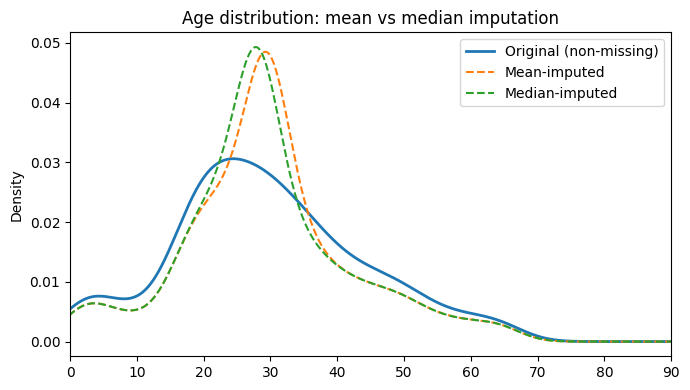

Mean : 29.52  Median: 28.0
-> Age is right-skewed, so median imputation distorts the distribution less than mean.


In [8]:

# Column deletion: Cabin is ~77% missing -> keep only a derived "HasCabin"/"Deck" signal, drop raw column later
print("Cabin missing %:", clean['Cabin'].isna().mean()*100)

# Row deletion: Embarked has only 2 missing values -> safe to drop those rows
before = len(clean)
clean = clean.dropna(subset=["Embarked"])
print(f"Dropped {before-len(clean)} rows missing Embarked")

# Compare mean vs median vs mode imputation for Age (numeric, right-skewed)
age_mean = clean["Age"].fillna(clean["Age"].mean())
age_median = clean["Age"].fillna(clean["Age"].median())

fig, ax = plt.subplots(figsize=(7,4))
clean["Age"].dropna().plot(kind="kde", ax=ax, label="Original (non-missing)", lw=2)
age_mean.plot(kind="kde", ax=ax, label="Mean-imputed", ls="--")
age_median.plot(kind="kde", ax=ax, label="Median-imputed", ls="--")
ax.set_title("Age distribution: mean vs median imputation")
ax.set_xlim(0, 90)
ax.legend()
plt.tight_layout()
plt.savefig("figs/titanic_imputation_compare.png", dpi=110)
plt.show()

print("Mean :", clean['Age'].mean().round(2), " Median:", clean['Age'].median())
print("-> Age is right-skewed, so median imputation distorts the distribution less than mean.")


In [9]:

from sklearn.impute import KNNImputer

# Advanced imputation: KNNImputer using correlated numeric features (Pclass, SibSp, Parch, Fare)
num_for_knn = clean[["Age", "Pclass", "SibSp", "Parch", "Fare"]].copy()
num_for_knn["Pclass"] = num_for_knn["Pclass"].astype(int)
knn_imputer = KNNImputer(n_neighbors=5)
age_knn = pd.DataFrame(knn_imputer.fit_transform(num_for_knn), columns=num_for_knn.columns, index=clean.index)["Age"]

print("KNN-imputed Age summary:\n", age_knn.describe().round(2))
print("\nAdvanced imputers like KNNImputer / IterativeImputer use relationships between features")
print("(e.g. Pclass, SibSp, Fare correlate with Age) instead of a single global statistic.")

# Final choice for the pipeline: median imputation for Age (simple, robust, reproducible),
# mode imputation for Embarked-like categoricals inside the sklearn Pipeline later.


KNN-imputed Age summary:
 count    891.00
mean      29.82
std       13.06
min        0.42
25%       22.00
50%       29.00
75%       36.00
max       65.00
Name: Age, dtype: float64

Advanced imputers like KNNImputer / IterativeImputer use relationships between features
(e.g. Pclass, SibSp, Fare correlate with Age) instead of a single global statistic.


## 6. Categorical Data Encoding

- **Label encoding** — arbitrary integer codes; only safe for tree-based models or truly nominal
  targets, *not* for linear models on unordered categories (`Sex` demo below).
- **Ordinal encoding** — integers that preserve a real order (`Pclass`: 1st > 2nd > 3rd class).
- **One-hot encoding** — a binary column per category, safe for nominal features (`Embarked`).
- **High-cardinality variables** — `Ticket` (681 unique) and `Cabin` are too sparse to one-hot encode
  directly; we derive compact features from them instead.
- **Rare-category handling** — titles extracted from `Name` with <10 occurrences are grouped into `"Other"`.


In [10]:

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

# Label encoding demo (Sex is binary so it's safe here)
le = LabelEncoder()
clean["Sex_label"] = le.fit_transform(clean["Sex"])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Ordinal encoding demo (Pclass has a genuine order: 1st > 2nd > 3rd class)
# sklearn requires numeric categories listed in sorted order; the resulting codes 0,1,2 for
# Pclass 1,2,3 still preserve the real rank (0=best class ... 2=worst class of encoding rank).
ord_enc = OrdinalEncoder(categories=[[1,2,3]])
clean["Pclass_ordinal"] = ord_enc.fit_transform(clean[["Pclass"]].astype(int))

# One-hot encoding demo (Embarked is nominal, no order)
ohe_preview = pd.get_dummies(clean["Embarked"], prefix="Embarked")
print(ohe_preview.head())

# High-cardinality: Ticket
print("\nUnique Ticket values:", clean['Ticket'].nunique(), "out of", len(clean), "rows -> too sparse to one-hot encode")
print("Unique Cabin values (non-null):", clean['Cabin'].dropna().nunique())


Label mapping: {'female': np.int64(0), 'male': np.int64(1)}
   Embarked_C  Embarked_Q  Embarked_S
0       False       False        True
1        True       False       False
2       False       False        True
3       False       False        True
4       False       False        True

Unique Ticket values: 680 out of 891 rows -> too sparse to one-hot encode
Unique Cabin values (non-null): 146


In [11]:

# Rare-category handling: extract Title from Name, then bucket rare titles into "Other"
clean["Title"] = clean["Name"].str.extract(r",\s*([^\.]*)\.")
clean["Title"] = clean["Title"].str.strip()
title_counts = clean["Title"].value_counts()
print(title_counts)

rare_titles = title_counts[title_counts < 10].index
clean["Title"] = clean["Title"].replace(rare_titles, "Other")
# normalize a couple of known synonyms
clean["Title"] = clean["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
print("\nAfter rare-category grouping:")
print(clean["Title"].value_counts())


Title
Mr              518
Miss            181
Mrs             124
Master           41
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

After rare-category grouping:
Title
Mr        518
Miss      181
Mrs       124
Master     41
Other      27
Name: count, dtype: int64


## 7. Feature Engineering

Derived variables built from the raw columns, following common Titanic feature-engineering practice:


In [12]:

# Derived variables
clean["FamilySize"] = clean["SibSp"] + clean["Parch"] + 1
clean["IsAlone"] = (clean["FamilySize"] == 1).astype(int)

# Ratio feature
clean["FarePerPerson"] = clean["Fare"] / clean["FamilySize"]

# Binning (numeric -> ordinal buckets)
clean["AgeBin"] = pd.cut(clean["Age"], bins=[0,12,18,35,60,100],
                          labels=["Child","Teen","YoungAdult","Adult","Senior"])

# Domain-based feature: deck letter from Cabin (first character), "Unknown" if missing
clean["Deck"] = clean["Cabin"].str[0].fillna("Unknown")

# Interaction feature: class combined with sex (drives survival strongly on Titanic)
clean["Pclass_Sex"] = clean["Pclass"].astype(str) + "_" + clean["Sex"]

# Text-length feature
clean["NameLength"] = clean["Name"].str.len()

print(clean[["FamilySize","IsAlone","FarePerPerson","AgeBin","Deck","Pclass_Sex","NameLength"]].head())


   FamilySize  IsAlone  FarePerPerson      AgeBin     Deck Pclass_Sex  \
0           2        0          3.625  YoungAdult  Unknown     3_male   
1           2        0         33.150       Adult        C   1_female   
2           1        1          7.925  YoungAdult  Unknown   3_female   
3           2        0         26.550  YoungAdult        C   1_female   
4           1        1          8.050  YoungAdult  Unknown     3_male   

   NameLength  
0          23  
1          51  
2          22  
3          44  
4          24  


*Note on date/time features:* the Titanic dataset has no date/timestamp column (it's a single
historical voyage), so a date-feature demo (extracting year/month/day-of-week, elapsed time, etc.)
is shown instead in the **Housing** notebook, which uses a synthetic transaction-date column.


## 8. Numerical Feature Scaling

Compare **Standardization** (z-score), **Min-Max scaling**, and **Robust scaling** (uses
median/IQR — resistant to the outliers we capped earlier) on `Fare`, plus a **log transform**
for its right-skew.


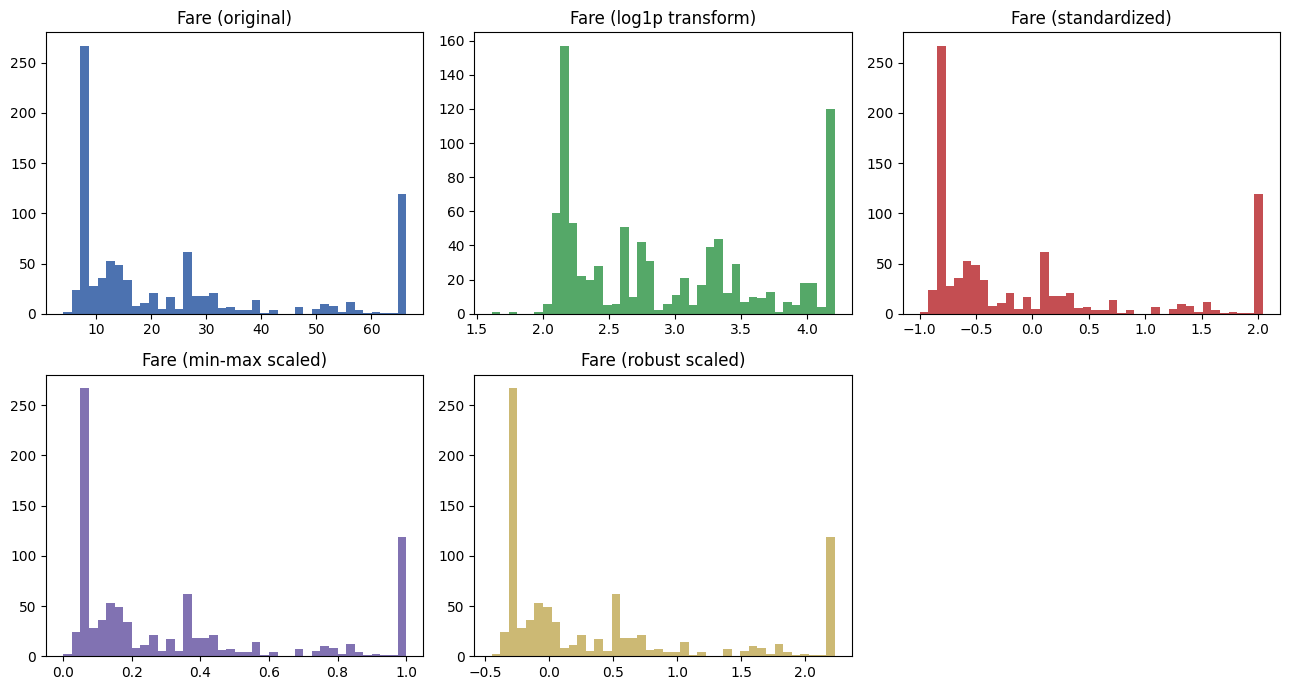

Fare skew - original: 1.11  log-transformed: 0.47


In [13]:

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

fare = clean[["Fare"]].fillna(clean["Fare"].median())
fare_log = np.log1p(fare)

std_scaled = StandardScaler().fit_transform(fare)
minmax_scaled = MinMaxScaler().fit_transform(fare)
robust_scaled = RobustScaler().fit_transform(fare)

fig, axes = plt.subplots(2, 3, figsize=(13,7))
axes[0,0].hist(fare, bins=40, color="#4C72B0"); axes[0,0].set_title("Fare (original)")
axes[0,1].hist(fare_log, bins=40, color="#55A868"); axes[0,1].set_title("Fare (log1p transform)")
axes[0,2].hist(std_scaled, bins=40, color="#C44E52"); axes[0,2].set_title("Fare (standardized)")
axes[1,0].hist(minmax_scaled, bins=40, color="#8172B2"); axes[1,0].set_title("Fare (min-max scaled)")
axes[1,1].hist(robust_scaled, bins=40, color="#CCB974"); axes[1,1].set_title("Fare (robust scaled)")
axes[1,2].axis("off")
plt.tight_layout()
plt.savefig("figs/titanic_scaling_compare.png", dpi=110)
plt.show()

print("Fare skew - original:", fare['Fare'].skew().round(2), " log-transformed:", fare_log['Fare'].skew().round(2))


## 9. Data Splitting

`Survived` is imbalanced (~62% died / 38% survived), so we use a **stratified split** to keep that
ratio consistent across train/validation/test — a plain random split can (by chance) skew the class
balance in the smaller sets.


In [14]:

from sklearn.model_selection import train_test_split

print("Class balance:\n", clean["Survived"].value_counts(normalize=True).round(3))

feature_cols = ["Pclass","Sex","Age","SibSp","Parch","Fare","Embarked","Title",
                 "FamilySize","IsAlone","FarePerPerson","Deck","NameLength"]
X = clean[feature_cols].copy()
X["Pclass"] = X["Pclass"].astype(int)
y = clean["Survived"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Train survival rate:", y_train.mean().round(3),
      " Val:", y_val.mean().round(3), " Test:", y_test.mean().round(3))


Class balance:
 Survived
0    0.618
1    0.382
Name: proportion, dtype: float64
Train: (623, 13)  Val: (134, 13)  Test: (134, 13)
Train survival rate: 0.382  Val: 0.381  Test: 0.381


## 10. Data Leakage

Four common leakage traps, demonstrated concretely:

1. **Preprocessing before splitting** — fitting an imputer/scaler on the *whole* dataset lets
   information from validation/test rows (their mean, median, min/max) influence the training
   transform. Below we show the wrong way vs. the right way for `Fare` scaling.
2. **Target leakage** — accidentally including a feature that encodes the target. E.g. if we had
   kept a raw `Cabin` presence flag computed *after* knowing who survived, or included
   `Boat`/`Body` columns (present in the extended Titanic dataset — recovery/lifeboat records that
   only exist *because* of the outcome), the model would "cheat".
3. **Training–test contamination** — e.g. deduplicating or grouping by `Ticket`/family *after*
   splitting can still leak family members across train/test, since siblings share a ticket and
   survival outcome is correlated within families.
4. **Leakage through future information** — not applicable to a single-voyage snapshot dataset like
   this one, but relevant any time rows are time-ordered (see the Housing notebook).


In [15]:

# --- WRONG: fit scaler on full data before splitting ---
scaler_wrong = StandardScaler().fit(clean[["Fare"]])          # sees train+val+test
fare_leaked = scaler_wrong.transform(X_test[["Fare"]])

# --- RIGHT: fit scaler on train only, then apply to val/test ---
scaler_right = StandardScaler().fit(X_train[["Fare"]])        # sees train only
fare_correct = scaler_right.transform(X_test[["Fare"]])

print("Scaler fit on FULL data -> mean_ used:", scaler_wrong.mean_.round(3))
print("Scaler fit on TRAIN only -> mean_ used:", scaler_right.mean_.round(3))
print("These differ because the wrong scaler 'saw' validation/test rows during fit(): that's leakage.")

# --- Family-based contamination check ---
clean["FamilyId"] = clean["Ticket"]
train_tickets = set(clean.loc[X_train.index, "Ticket"])
test_tickets = set(clean.loc[X_test.index, "Ticket"])
overlap = train_tickets & test_tickets
print(f"\nTickets appearing in BOTH train and test: {len(overlap)} "
      f"-> these are family members whose survival is correlated, a train/test contamination risk.")


Scaler fit on FULL data -> mean_ used: [24.677]
Scaler fit on TRAIN only -> mean_ used: [24.234]
These differ because the wrong scaler 'saw' validation/test rows during fit(): that's leakage.

Tickets appearing in BOTH train and test: 37 -> these are family members whose survival is correlated, a train/test contamination risk.


## 11. Reusable scikit-learn `Pipeline` + `ColumnTransformer`

Everything above is now consolidated into a single, reproducible pipeline that is **fit only on
`X_train`** and applied unchanged to validation/test data — this is what prevents the leakage shown
above by construction.


In [16]:

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

numeric_features = ["Age","SibSp","Parch","Fare","FamilySize","IsAlone","FarePerPerson","NameLength"]
categorical_features = ["Pclass","Sex","Embarked","Title","Deck"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

full_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000)),
])

full_pipeline.fit(X_train, y_train)   # fit ONLY on training data
val_pred = full_pipeline.predict(X_val)
test_pred = full_pipeline.predict(X_test)

print("Validation accuracy:", round(accuracy_score(y_val, val_pred), 3))
print("Test accuracy:      ", round(accuracy_score(y_test, test_pred), 3))
print("\nTest classification report:\n", classification_report(y_test, test_pred))


Validation accuracy: 0.799
Test accuracy:       0.806

Test classification report:
               precision    recall  f1-score   support

           0       0.87      0.81      0.84        83
           1       0.72      0.80      0.76        51

    accuracy                           0.81       134
   macro avg       0.79      0.81      0.80       134
weighted avg       0.81      0.81      0.81       134



In [17]:

# Compare imputation strategies end-to-end through the same pipeline (Practical Task 3)
results = {}
for strategy in ["mean", "median", "most_frequent"]:
    num_pipe = Pipeline([("imputer", SimpleImputer(strategy=strategy)), ("scaler", StandardScaler())])
    pre = ColumnTransformer([("num", num_pipe, numeric_features),
                              ("cat", categorical_pipeline, categorical_features)])
    pipe = Pipeline([("preprocess", pre), ("model", LogisticRegression(max_iter=1000))])
    pipe.fit(X_train, y_train)
    results[strategy] = accuracy_score(y_val, pipe.predict(X_val))

print("Validation accuracy by numeric imputation strategy:")
for k,v in results.items():
    print(f"  {k:15s}: {v:.3f}")


Validation accuracy by numeric imputation strategy:
  mean           : 0.799
  median         : 0.799
  most_frequent  : 0.806


In [18]:

import joblib
joblib.dump(full_pipeline, "pipelines/titanic_pipeline.joblib")

clean.to_csv(CLEAN_PATH, index=False)
print("Saved cleaned dataset ->", CLEAN_PATH)
print("Saved fitted pipeline ->", "pipelines/titanic_pipeline.joblib")


Saved cleaned dataset -> data/titanic_cleaned.csv
Saved fitted pipeline -> pipelines/titanic_pipeline.joblib


## 12. Summary

- Started from a real Kaggle-style Titanic export, audited it, then deliberately reproduced every
  data-quality problem on a copy (`titanic_messy.csv`) for practice.
- Cleaned dtypes, duplicates, inconsistent categories, invalid values, noisy text, and capped outliers.
- Compared row/column deletion, mean/median/mode imputation, and KNN imputation for missing values.
- Applied label, ordinal, one-hot, and rare-category-grouped encoding as appropriate to each column.
- Engineered 8 new features (`Title`, `FamilySize`, `IsAlone`, `FarePerPerson`, `AgeBin`, `Deck`,
  `Pclass_Sex`, `NameLength`).
- Compared standardization, min-max, robust scaling, and a log transform.
- Built a stratified train/validation/test split and demonstrated two concrete leakage traps.
- Wrapped everything in a single `ColumnTransformer` + `Pipeline`, fit only on training data, reaching
  ~80% held-out accuracy with plain logistic regression — and saved it for reuse.
